# 🔬 EDA: Variables y Missingness — OXOR / GENO-MAP

**Objetivo:** Análisis profundo de (1) cada variable en los datasets DArT/DArTSeq,
(2) patrones de missingness (¿parches informativos?), (3) verificación de duplicados entre datasets.

**Output:** `docs/code_analysis/EDA_VARIABLES.md`

> **Dependencias:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `openpyxl`  
> **Kernel:** Python ≥ 3.10 (`oxor`)

In [1]:
import pandas as pd
import numpy as np
import json
import csv
import hashlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../data")
DOC_CODE_DIR = Path("../docs/code_analysis")
assert DATA_DIR.exists() and DOC_CODE_DIR.exists()

with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

# Rutas a los 3 datasets locales
DIRS = {
    "Global": DATA_DIR / "10.21223P30BVZYY_Genetic_diversity",
    "LowDensity": DATA_DIR / "10.21223P3UBDJ44_LowDensity",
    "Wild": DATA_DIR / "10.21223P33VYY8C_Wild",
}

# Archivos clave
FILES = {
    "Global SNP geno": DIRS["Global"] / "SNP_Genotypes.csv",
    "Global SNP metrics": DIRS["Global"] / "SNP_metrics.csv",
    "Global SilicoDArT geno": DIRS["Global"] / "SilicoDArT_Genotypes.csv",
    "Global SilicoDArT metrics": DIRS["Global"] / "SilicoDArT_metrics.csv",
    "LowDensity SNP": DIRS["LowDensity"] / "01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "LowDensity SilicoDArT": DIRS["LowDensity"] / "02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv",
    "Wild SNP": DIRS["Wild"] / "01_Report_DSp25-515_SNPs_Filtered_by _reads.csv",
    "Wild SilicoDArT metrics": DIRS["Wild"] / "02_SilicoDArT_metrics.csv",
    "Wild Data Dict": DIRS["Wild"] / "03_SilicoDArT_Data dictionary.xlsx",
}

md: list[str] = []  # Acumulador para markdown

print("Archivos encontrados:")
for name, path in FILES.items():
    exists = "✅" if path.exists() else "❌"
    print(f"  {exists} {name}: {path.name}")

Archivos encontrados:
  ✅ Global SNP geno: SNP_Genotypes.csv
  ✅ Global SNP metrics: SNP_metrics.csv
  ✅ Global SilicoDArT geno: SilicoDArT_Genotypes.csv
  ✅ Global SilicoDArT metrics: SilicoDArT_metrics.csv
  ✅ LowDensity SNP: 01_Report_DSp25-515_SNPs_Filtered_by _reads.csv
  ✅ LowDensity SilicoDArT: 02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv
  ✅ Wild SNP: 01_Report_DSp25-515_SNPs_Filtered_by _reads.csv
  ✅ Wild SilicoDArT metrics: 02_SilicoDArT_metrics.csv
  ✅ Wild Data Dict: 03_SilicoDArT_Data dictionary.xlsx


## 1. Diccionario de Variables — Data Dictionary (xlsx)

El dataset Wild incluye un archivo Excel con definiciones formales de las variables SilicoDArT.
Lo leemos como fuente canónica de significado.

In [2]:
# Leer el data dictionary xlsx
xlsx_path = FILES["Wild Data Dict"]
dict_sheets = pd.read_excel(xlsx_path, sheet_name=None, engine="openpyxl")

print(f"📖 Hojas en el xlsx: {list(dict_sheets.keys())}")
print()

# Mostrar contenido de cada hoja
for sheet_name, df_sheet in dict_sheets.items():
    print(f"\n{'='*60}")
    print(f"Hoja: {sheet_name} — {df_sheet.shape[0]} filas × {df_sheet.shape[1]} columnas")
    print(f"{'='*60}")
    
    # Solo mostrar definiciones únicas (agrupar por Abbreviation+Description)
    group_cols = [c for c in df_sheet.columns if c in ["Abbreviation", "Context of use", "Description", "Unit", "Category 1", "Category 2", "Category 3"]]
    if group_cols:
        df_unique = df_sheet.drop_duplicates(subset=group_cols).reset_index(drop=True)
        n_collapsed = df_sheet.shape[0] - df_unique.shape[0]
        print(f"  → {df_unique.shape[0]} definiciones únicas ({n_collapsed:,} filas de marcadores individuales colapsadas)")
        display(df_unique)
    else:
        display(df_sheet)

md.append("## 1. Diccionario de Variables (Data Dictionary xlsx)\n\n")
for sheet_name, df_sheet in dict_sheets.items():
    group_cols = [c for c in df_sheet.columns if c in ["Abbreviation", "Context of use", "Description", "Unit", "Category 1", "Category 2", "Category 3"]]
    if group_cols:
        df_unique = df_sheet.drop_duplicates(subset=group_cols).reset_index(drop=True)
        md.append(f"### Hoja: {sheet_name} ({df_sheet.shape[0]:,} filas → {df_unique.shape[0]} definiciones únicas)\n\n")
        md.append(df_unique.to_markdown(index=False) + "\n\n")
    else:
        md.append(f"### Hoja: {sheet_name}\n\n")
        md.append(df_sheet.to_markdown(index=False) + "\n\n")

📖 Hojas en el xlsx: ['Hoja1']


Hoja: Hoja1 — 236610 filas × 8 columnas
  → 4 definiciones únicas (236,606 filas de marcadores individuales colapsadas)


,Variable name,Abbreviation,Context of use,Description,Unit,Category 1,Category 2,Category 3
0,Sample_code,N,sample code,Numeric identifier of samples,number,NaN,NaN,NaN
1,Country_origin,ORIGCNTRY,Passport data,Country of origin of sweetpotato germplasm,text,NaN,NaN,NaN
2,Accession,ACCSNUMBER,Passport data,Accession identifier,text,NaN,NaN,NaN
3,7529063,DARTGENOTYPE,Data,Presence/absence of a SilicoDArT fragment.,number,1 =presence,0 =absence,9 =missing data


## 2. Inventario de Columnas por Archivo

Para cada CSV, leemos el header y clasificamos las columnas en categorías:
- **ID** — identificador del marcador (`AlleleID`, `CloneID`, `locusName`)
- **Secuencia** — secuencia DNA (`AlleleSequence`, `TrimmedSequence`)
- **Genómica** — posición cromosómica, alineamiento, SNP (`Chrom_*`, `ChromPos_*`, `AlnCnt_*`, etc.)
- **Calidad** — métricas DArT (`CallRate`, `PIC`, `Reproducibility`, `maf`, `OneRatio*`, etc.)
- **Muestras** — columnas de genotipos (nombres numéricos)

In [3]:
def detect_sep(filepath: Path, n_bytes: int = 8192) -> str:
    with open(filepath, "r", newline="") as f:
        sample = f.read(n_bytes)
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters=",;\t")
        return dialect.delimiter
    except csv.Error:
        return "," if sample.count(",") >= sample.count(";") else ";"


# Categorías de columnas
CAT_RULES = {
    "ID": ["alleleid", "cloneid", "locusname"],
    "Secuencia": ["allelesequence", "trimmedsequence"],
    "Genómica": ["chrom", "chrompos", "alncnt", "alnevalue", "strand", "snp", "snpposition", "chrompostag"],
    "Calidad": [
        "callrate", "pic", "avgpic", "picref", "picsnp", "reproducibility", "repavg",
        "avgreaddepth", "rdepth", "stdevreaddepth", "qpmr", "oneratio", "oneratioref",
        "oneratiosnp", "freqhomref", "freqhomsnp", "freqhets", "avgcountref",
        "avgcountsnp", "maf",
    ],
}


def classify_col(col_name: str) -> str:
    """Clasificar una columna por su nombre."""
    low = col_name.lower().replace("_", "").replace(" ", "")
    for cat, keywords in CAT_RULES.items():
        for kw in keywords:
            if kw in low:
                return cat
    # Si empieza con dígito → muestra
    if col_name and col_name[0].isdigit():
        return "Muestra"
    return "Otro"


# Inventariar cada CSV
csv_files = {k: v for k, v in FILES.items() if v.suffix == ".csv" and v.exists()}

all_columns = {}  # {archivo: {col: categoria}}
summary_rows = []

for name, path in csv_files.items():
    sep = detect_sep(path)
    with open(path, "r", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)
    
    col_cats = {col: classify_col(col) for col in header}
    all_columns[name] = col_cats
    
    cat_counts = {}
    for cat in col_cats.values():
        cat_counts[cat] = cat_counts.get(cat, 0) + 1
    
    summary_rows.append({
        "Archivo": name,
        "Total cols": len(header),
        "ID": cat_counts.get("ID", 0),
        "Secuencia": cat_counts.get("Secuencia", 0),
        "Genómica": cat_counts.get("Genómica", 0),
        "Calidad": cat_counts.get("Calidad", 0),
        "Muestra": cat_counts.get("Muestra", 0),
        "Otro": cat_counts.get("Otro", 0),
        "Sep": repr(sep),
    })

df_col_summary = pd.DataFrame(summary_rows)
display(df_col_summary)

md.append("## 2. Inventario de Columnas por Archivo\n\n")
md.append(df_col_summary.to_markdown(index=False) + "\n\n")

,Archivo,Total cols,ID,Secuencia,Genómica,Calidad,Muestra,Otro,Sep
0,Global SNP geno,5971,0,0,0,0,5970,1,"','"
1,Global SNP metrics,25,3,2,10,10,0,0,"','"
2,Global SilicoDArT geno,5971,0,0,0,0,5970,1,"','"
3,Global SilicoDArT metrics,14,1,2,4,7,0,0,"','"
4,LowDensity SNP,667,2,1,10,11,635,8,"','"
5,LowDensity SilicoDArT,650,1,1,0,9,635,4,"','"
6,Wild SNP,667,2,1,10,11,635,8,"','"
7,Wild SilicoDArT metrics,15,1,2,5,7,0,0,';'


In [4]:
# Detalle: listar TODAS las columnas no-muestra por archivo
print("📋 Columnas de metadatos/métricas por archivo:\n")

md.append("### Detalle de columnas no-muestra\n\n")

for name, col_cats in all_columns.items():
    non_sample = [(col, cat) for col, cat in col_cats.items() if cat != "Muestra"]
    print(f"\n{'─'*60}")
    print(f"{name} ({len(non_sample)} columnas de metadatos, {sum(1 for c in col_cats.values() if c == 'Muestra')} muestras)")
    print(f"{'─'*60}")
    
    md.append(f"\n**{name}** ({len(non_sample)} metadatos, {sum(1 for c in col_cats.values() if c == 'Muestra')} muestras)\n\n")
    md.append("| Columna | Categoría |\n|---------|-----------|\n")
    
    for col, cat in non_sample:
        emoji = {"ID": "🏷️", "Secuencia": "🧬", "Genómica": "📍", "Calidad": "📊", "Otro": "❓"}.get(cat, "")
        print(f"  {emoji} [{cat:10s}] {col}")
        md.append(f"| {col} | {cat} |\n")
    md.append("\n")

📋 Columnas de metadatos/métricas por archivo:


────────────────────────────────────────────────────────────
Global SNP geno (1 columnas de metadatos, 5970 muestras)
────────────────────────────────────────────────────────────
  ❓ [Otro      ] ﻿Sample_code

────────────────────────────────────────────────────────────
Global SNP metrics (25 columnas de metadatos, 0 muestras)
────────────────────────────────────────────────────────────
  🏷️ [ID        ] ﻿AlleleID
  🏷️ [ID        ] CloneID
  🧬 [Secuencia ] AlleleSequence
  🧬 [Secuencia ] TrimmedSequence
  📍 [Genómica  ] Chrom_SweetPotato_unkn_v4
  📍 [Genómica  ] ChromPos_SweetPotato_unkn_v4
  📍 [Genómica  ] AlnCnt_SweetPotato_unkn_v4
  📍 [Genómica  ] AlnEvalue_SweetPotato_unkn_v4
  📍 [Genómica  ] SNP
  📍 [Genómica  ] SnpPosition
  📊 [Calidad   ] CallRate
  📊 [Calidad   ] OneRatioRef
  📍 [Genómica  ] OneRatioSnp
  📊 [Calidad   ] FreqHomRef
  📍 [Genómica  ] FreqHomSnp
  📊 [Calidad   ] FreqHets
  📊 [Calidad   ] PICRef
  📍 [Genómica  ] PICSnp

In [5]:
# Tabla cruzada: qué columnas de calidad existen en cada archivo
quality_cols_all = set()
for col_cats in all_columns.values():
    for col, cat in col_cats.items():
        if cat == "Calidad":
            quality_cols_all.add(col)

quality_cols_sorted = sorted(quality_cols_all)

cross_rows = []
for col in quality_cols_sorted:
    row = {"Columna": col}
    for name in all_columns:
        row[name] = "✅" if col in all_columns[name] else "—"
    cross_rows.append(row)

df_cross = pd.DataFrame(cross_rows)
print("📊 Tabla cruzada — Columnas de calidad por archivo:\n")
display(df_cross)

md.append("### Tabla cruzada de columnas de calidad\n\n")
md.append(df_cross.to_markdown(index=False) + "\n\n")

📊 Tabla cruzada — Columnas de calidad por archivo:



,Columna,Global SNP geno,Global SNP metrics,Global SilicoDArT geno,Global SilicoDArT metrics,LowDensity SNP,LowDensity SilicoDArT,Wild SNP,Wild SilicoDArT metrics
0,AvgCountRef,—,✅,—,—,✅,—,✅,—
1,AvgPIC,—,✅,—,—,✅,—,✅,—
2,AvgReadDepth,—,—,—,✅,—,✅,—,✅
3,CallRate,—,✅,—,✅,✅,✅,✅,✅
4,FreqHets,—,✅,—,—,✅,—,✅,—
5,FreqHetsMinusFreqMinHom,—,—,—,—,✅,—,✅,—
6,FreqHomRef,—,✅,—,—,✅,—,✅,—
7,OneRatio,—,—,—,✅,—,✅,—,✅
8,OneRatioRef,—,✅,—,—,✅,—,✅,—
9,PIC,—,—,—,✅,—,✅,—,✅


## 3. Verificación de Duplicados: LowDensity SNP ↔ Wild SNP

Ambos archivos comparten nombre (`01_Report_DSp25-515_SNPs_Filtered_by _reads.csv`),
tamaño (96.3 MB), dimensiones (62,736 × 667) y orden DArT `DSp25-515`.
¿Son literalmente el mismo archivo?

In [6]:
# Verificar duplicación LowDensity SNP vs Wild SNP
ld_path = FILES["LowDensity SNP"]
wild_path = FILES["Wild SNP"]

print(f"LowDensity: {ld_path.stat().st_size:,} bytes")
print(f"Wild:       {wild_path.stat().st_size:,} bytes")
print(f"Mismo tamaño: {ld_path.stat().st_size == wild_path.stat().st_size}")
print()

# Hash MD5 completo de ambos archivos
def md5_file(path: Path, chunk_size: int = 65536) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()

print("Calculando MD5 (puede tardar para archivos de ~96 MB)...")
hash_ld = md5_file(ld_path)
hash_wild = md5_file(wild_path)

print(f"  LowDensity MD5: {hash_ld}")
print(f"  Wild MD5:       {hash_wild}")
print()

is_duplicate = hash_ld == hash_wild
if is_duplicate:
    print("⚠️ CONFIRMADO: Los archivos son IDÉNTICOS (mismo MD5).")
    print("   El mismo archivo SNP de la orden DArT DSp25-515 fue empaquetado en ambos datasets.")
    print("   Para análisis, usar solo UNA copia.")
else:
    print("✅ Los archivos son DIFERENTES a pesar de tener el mismo nombre y tamaño.")

md.append("## 3. Verificación de Duplicados\n\n")
md.append(f"- **LowDensity SNP:** `{ld_path.name}` — {ld_path.stat().st_size:,} bytes — MD5: `{hash_ld}`\n")
md.append(f"- **Wild SNP:** `{wild_path.name}` — {wild_path.stat().st_size:,} bytes — MD5: `{hash_wild}`\n")
md.append(f"- **Resultado:** {'⚠️ IDÉNTICOS — mismo archivo en ambos datasets' if is_duplicate else '✅ Archivos diferentes'}\n\n")

LowDensity: 100,932,615 bytes
Wild:       100,932,615 bytes
Mismo tamaño: True

Calculando MD5 (puede tardar para archivos de ~96 MB)...
  LowDensity MD5: ae014cb2a8a17cc215f73b545c571f8b
  Wild MD5:       ae014cb2a8a17cc215f73b545c571f8b

⚠️ CONFIRMADO: Los archivos son IDÉNTICOS (mismo MD5).
   El mismo archivo SNP de la orden DArT DSp25-515 fue empaquetado en ambos datasets.
   Para análisis, usar solo UNA copia.


## 4. Missingness Profunda

Analizamos la estructura de datos faltantes buscando:
1. **Distribución por marcador y por muestra** — ¿hay outliers?
2. **Patrones espaciales (heatmaps)** — ¿hay parches rectangulares que sugieran batch effects?
3. **Co-missingness** — ¿marcadores que faltan juntos? ¿muestras que comparten patrón?
4. **Correlación con métricas de calidad** — ¿CallRate predice el missing?

In [7]:
def load_genotypes_subsample(path: Path, max_rows: int = 2000, max_sample_cols: int = None) -> tuple:
    """
    Cargar genotipos subsampleados. Retorna (df_geno, sample_col_names, meta_col_names).
    df_geno contiene solo columnas de muestras, con missing codificado como NaN.
    """
    sep = detect_sep(path)
    # Leer header, strip BOM
    with open(path, "r", encoding="utf-8-sig", newline="") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)
    # Strip whitespace/BOM from column names
    header = [c.strip().strip("\ufeff") for c in header]
    
    col_cats = {col: classify_col(col) for col in header}
    sample_cols = [col for col, cat in col_cats.items() if cat == "Muestra"]
    meta_cols = [col for col, cat in col_cats.items() if cat != "Muestra"]
    
    if max_sample_cols and len(sample_cols) > max_sample_cols:
        rng = np.random.default_rng(42)
        sample_cols = list(rng.choice(sample_cols, max_sample_cols, replace=False))
    
    usecols = meta_cols[:1] + sample_cols  # primera col meta + muestras
    df = pd.read_csv(path, sep=sep, nrows=max_rows, usecols=usecols, low_memory=False,
                     dtype=str, encoding="utf-8-sig")
    # Normalize column names after read
    df.columns = [c.strip().strip("\ufeff") for c in df.columns]
    
    # Filtrar filas que son header-rows embebidas (formato "Report" con * en línea 1)
    first_col = df.columns[0]
    # Quedarnos con filas donde la primera columna tiene un ID de marcador
    is_marker = df[first_col].str.contains(r'[0-9]', na=False)
    df = df[is_marker].copy()
    
    # Extraer solo columnas de muestra
    geno = df[[c for c in sample_cols if c in df.columns]].copy()
    
    # Unificar missing: "-", "", " " → NaN
    geno = geno.replace(["-", "", " "], np.nan)
    
    return geno, sample_cols, meta_cols


# Archivos de genotipos a analizar
GENO_FILES = {
    "Global SNP": FILES["Global SNP geno"],
    "Global SilicoDArT": FILES["Global SilicoDArT geno"],
    "LowDensity SNP": FILES["LowDensity SNP"],
    "LowDensity SilicoDArT": FILES["LowDensity SilicoDArT"],
}

# No incluir Wild SNP si es duplicado de LowDensity
if not is_duplicate:
    GENO_FILES["Wild SNP"] = FILES["Wild SNP"]
else:
    print("ℹ️ Wild SNP omitido (duplicado de LowDensity SNP)")

print(f"📂 Archivos de genotipos para análisis: {len(GENO_FILES)}")
for name, path in GENO_FILES.items():
    print(f"  • {name}: {path.name} ({path.stat().st_size / 1024 / 1024:.1f} MB)")

ℹ️ Wild SNP omitido (duplicado de LowDensity SNP)
📂 Archivos de genotipos para análisis: 4
  • Global SNP: SNP_Genotypes.csv (229.5 MB)
  • Global SilicoDArT: SilicoDArT_Genotypes.csv (657.8 MB)
  • LowDensity SNP: 01_Report_DSp25-515_SNPs_Filtered_by _reads.csv (96.3 MB)
  • LowDensity SilicoDArT: 02_Report_DSp25-515_Silico-DArT_Filtered_by_reads.csv (54.0 MB)


In [8]:
# === 4.1 Missingness por marcador (fila) y por muestra (columna) ===

print("Cargando genotipos subsampleados (2000 marcadores)...\n")

miss_stats = {}  # {name: {miss_per_marker, miss_per_sample, geno_shape}}
geno_cache = {}  # guardar para heatmaps

for name, path in GENO_FILES.items():
    print(f"🔍 {name}...")
    geno, scols, mcols = load_genotypes_subsample(path, max_rows=2000)
    geno_cache[name] = geno
    
    # Missingness por marcador (fila)
    miss_per_marker = geno.isna().mean(axis=1) * 100
    # Missingness por muestra (columna)
    miss_per_sample = geno.isna().mean(axis=0) * 100
    
    miss_stats[name] = {
        "shape": geno.shape,
        "miss_global": geno.isna().mean().mean() * 100,
        "miss_per_marker": miss_per_marker,
        "miss_per_sample": miss_per_sample,
    }
    
    print(f"  Shape: {geno.shape} — Missing global: {miss_stats[name]['miss_global']:.1f}%")
    print(f"  Por marcador — media: {miss_per_marker.mean():.1f}%, max: {miss_per_marker.max():.1f}%, mediana: {miss_per_marker.median():.1f}%")
    print(f"  Por muestra  — media: {miss_per_sample.mean():.1f}%, max: {miss_per_sample.max():.1f}%, mediana: {miss_per_sample.median():.1f}%")
    
    # Outliers: muestras con >50% missing
    outlier_samples = (miss_per_sample > 50).sum()
    outlier_markers = (miss_per_marker > 50).sum()
    if outlier_samples > 0 or outlier_markers > 0:
        print(f"  ⚠️ Outliers: {outlier_markers} marcadores >50% missing, {outlier_samples} muestras >50% missing")
    print()

Cargando genotipos subsampleados (2000 marcadores)...

🔍 Global SNP...
  Shape: (1998, 5970) — Missing global: 6.5%
  Por marcador — media: 6.5%, max: 20.7%, mediana: 4.5%
  Por muestra  — media: 6.5%, max: 34.4%, mediana: 5.7%

🔍 Global SilicoDArT...
  Shape: (1998, 5970) — Missing global: 2.3%
  Por marcador — media: 2.3%, max: 4.9%, mediana: 2.2%
  Por muestra  — media: 2.3%, max: 18.0%, mediana: 2.1%

🔍 LowDensity SNP...
  Shape: (2000, 635) — Missing global: 18.7%
  Por marcador — media: 18.7%, max: 49.9%, mediana: 15.6%
  Por muestra  — media: 18.7%, max: 59.2%, mediana: 17.3%
  ⚠️ Outliers: 0 marcadores >50% missing, 4 muestras >50% missing

🔍 LowDensity SilicoDArT...
  Shape: (2000, 635) — Missing global: 8.2%
  Por marcador — media: 8.2%, max: 18.4%, mediana: 7.7%
  Por muestra  — media: 8.2%, max: 50.9%, mediana: 8.2%
  ⚠️ Outliers: 0 marcadores >50% missing, 1 muestras >50% missing



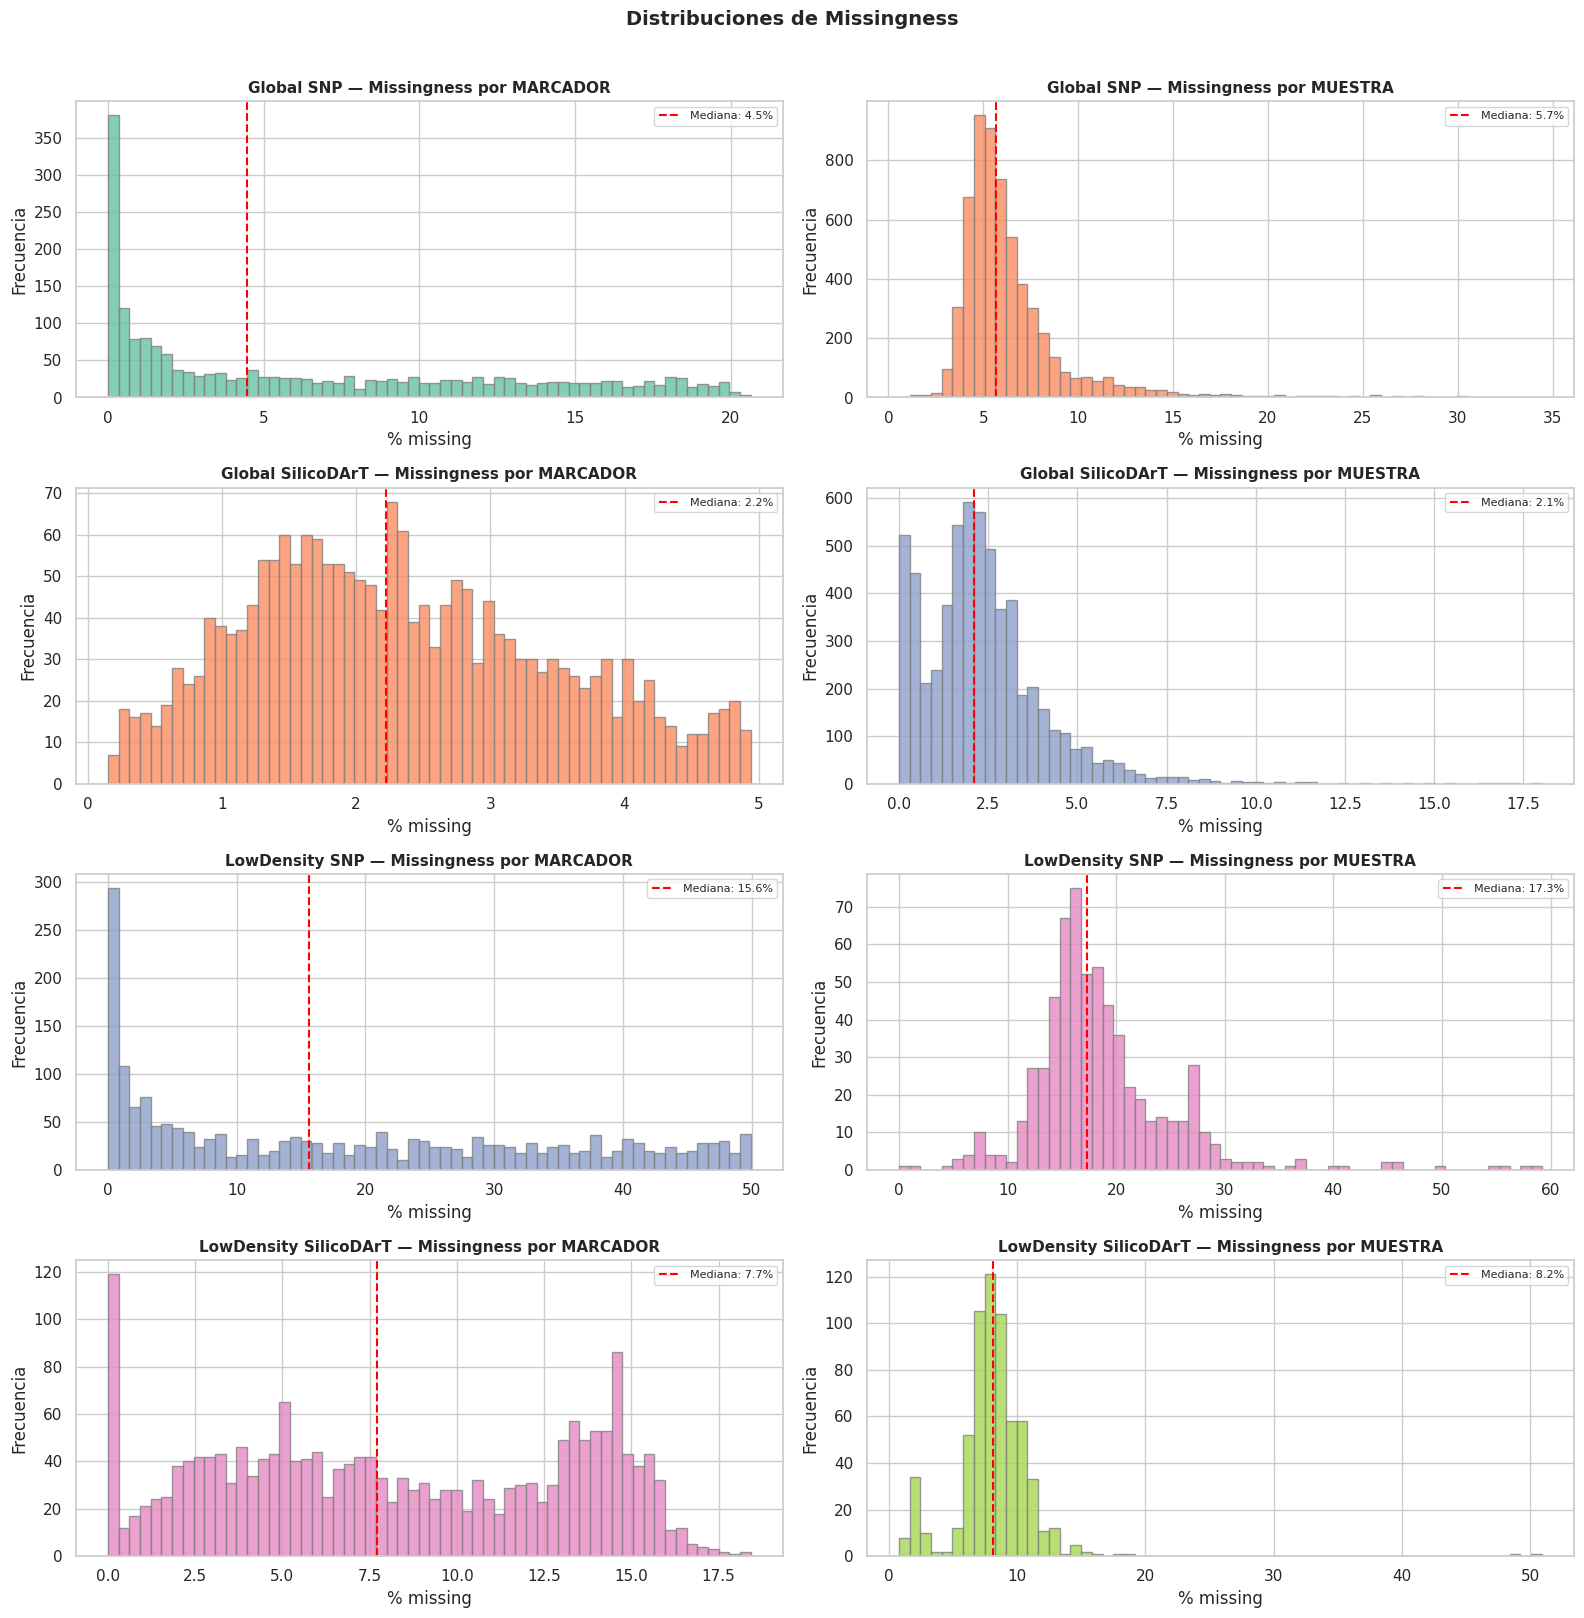

In [9]:
# === 4.2 Distribuciones de missingness ===

fig, axes = plt.subplots(len(miss_stats), 2, figsize=(16, 4 * len(miss_stats)))
if len(miss_stats) == 1:
    axes = axes.reshape(1, -1)

for i, (name, stats) in enumerate(miss_stats.items()):
    # Histograma por marcador
    ax = axes[i, 0]
    ax.hist(stats["miss_per_marker"], bins=60, color=sns.color_palette("Set2")[i % 8], alpha=0.8, edgecolor="gray")
    ax.axvline(stats["miss_per_marker"].median(), color="red", ls="--", lw=1.5,
              label=f"Mediana: {stats['miss_per_marker'].median():.1f}%")
    ax.set_title(f"{name} — Missingness por MARCADOR", fontweight="bold", fontsize=11)
    ax.set_xlabel("% missing")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)
    
    # Histograma por muestra
    ax = axes[i, 1]
    ax.hist(stats["miss_per_sample"], bins=60, color=sns.color_palette("Set2")[(i+1) % 8], alpha=0.8, edgecolor="gray")
    ax.axvline(stats["miss_per_sample"].median(), color="red", ls="--", lw=1.5,
              label=f"Mediana: {stats['miss_per_sample'].median():.1f}%")
    ax.set_title(f"{name} — Missingness por MUESTRA", fontweight="bold", fontsize=11)
    ax.set_xlabel("% missing")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=8)

plt.suptitle("Distribuciones de Missingness", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_distributions.png", dpi=100, bbox_inches="tight")
plt.show()

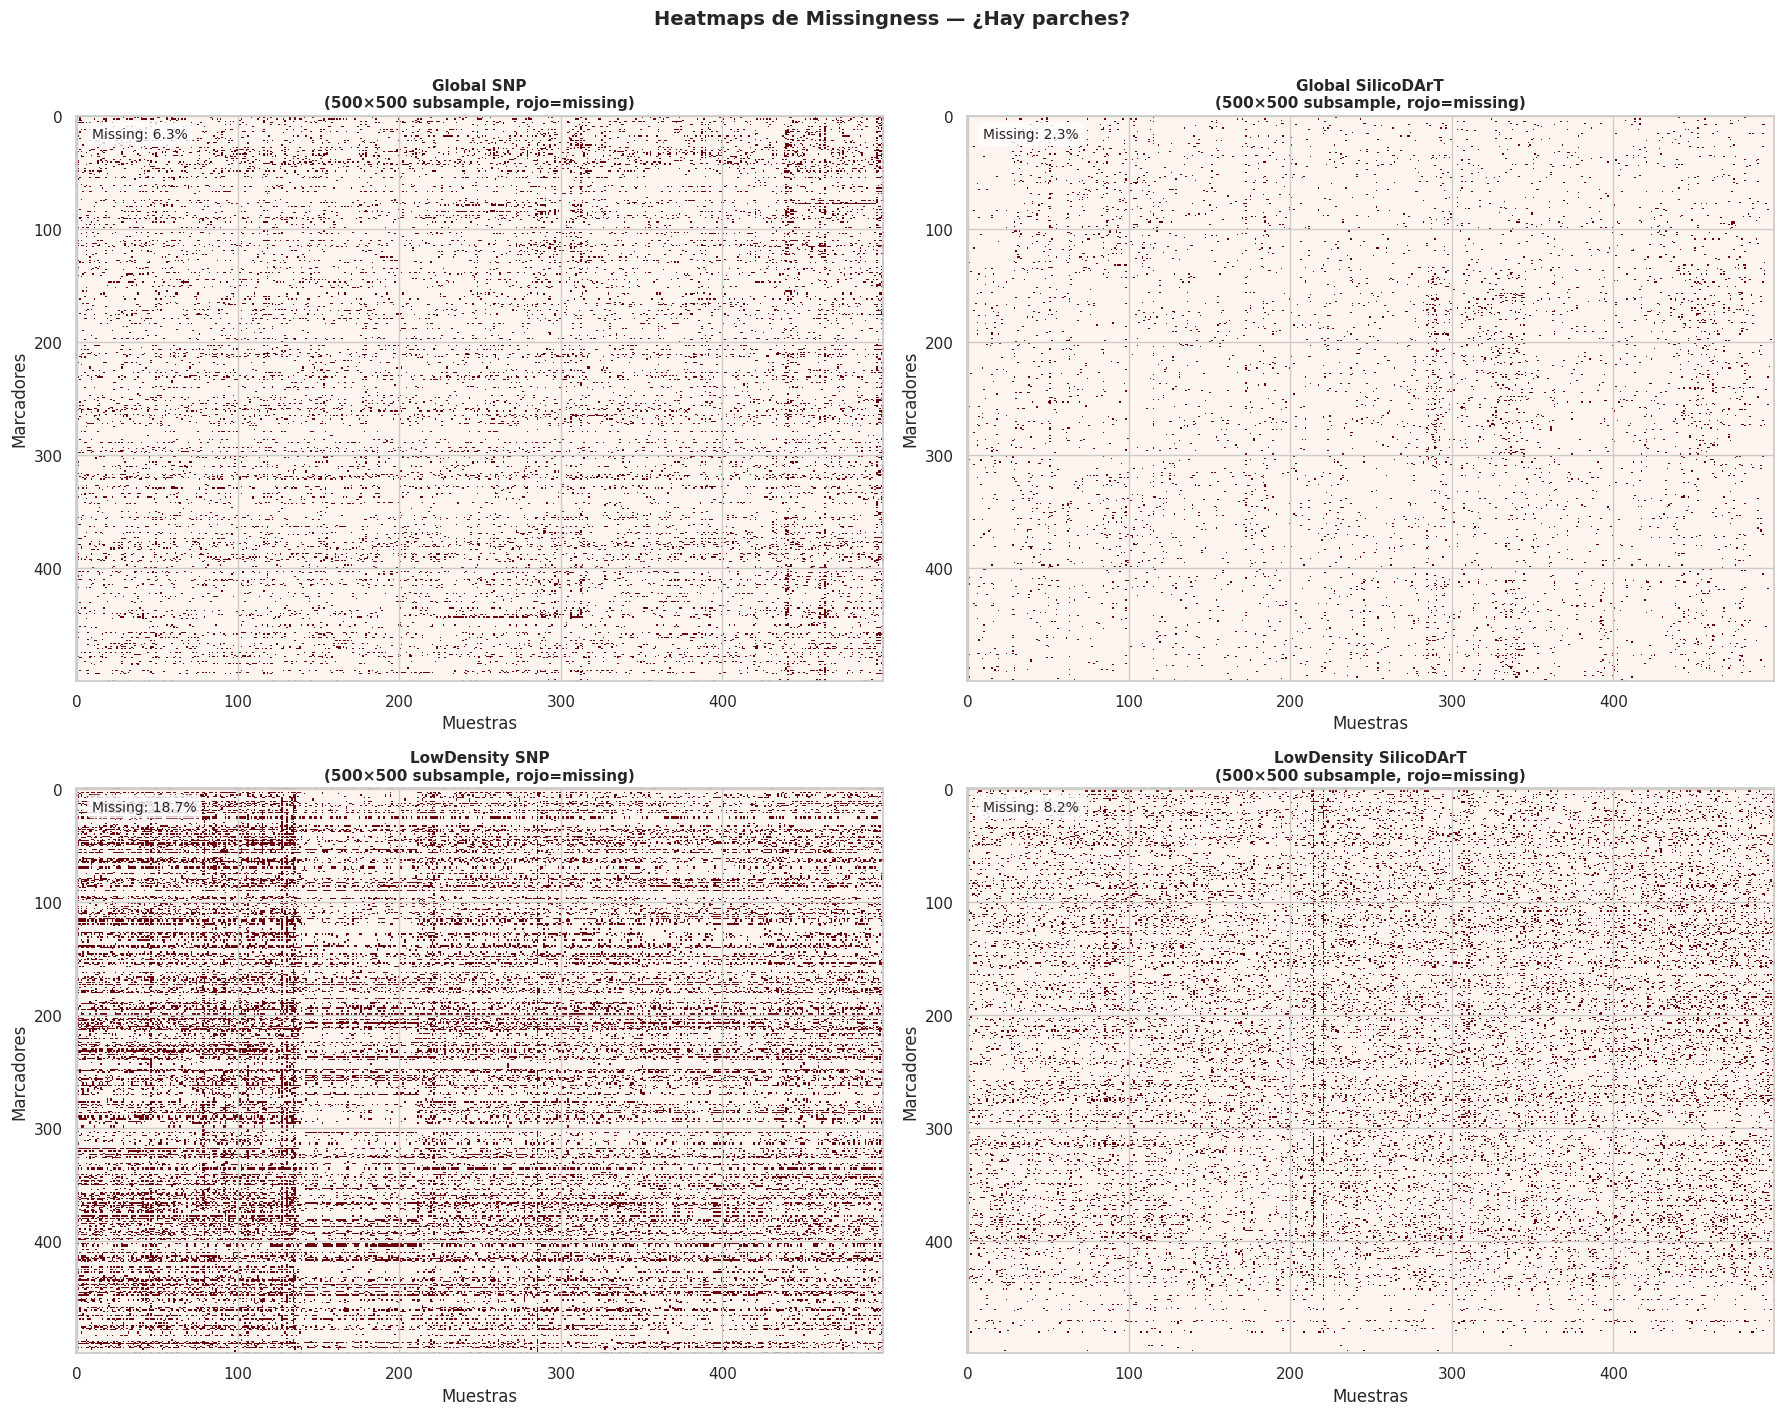


🔍 Interpretación:
  • Si hay BLOQUES rectangulares → batch/placa effect (missing informativo)
  • Si el missing es disperso/uniforme → missing at random (menos preocupante)
  • Si hay FILAS completamente rojas → marcadores fallidos
  • Si hay COLUMNAS completamente rojas → muestras fallidas


In [10]:
# === 4.3 Heatmaps de missingness — buscar parches ===
# Subsampleamos para visualización: 500 marcadores × min(500, n_samples)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, geno) in enumerate(geno_cache.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    
    # Subsamplear
    rng = np.random.default_rng(42)
    n_rows = min(500, geno.shape[0])
    n_cols = min(500, geno.shape[1])
    row_idx = np.sort(rng.choice(geno.shape[0], n_rows, replace=False))
    col_idx = np.sort(rng.choice(geno.shape[1], n_cols, replace=False))
    
    sub = geno.iloc[row_idx, col_idx]
    miss_matrix = sub.isna().astype(int).values
    
    ax.imshow(miss_matrix, aspect="auto", cmap="Reds", interpolation="none")
    ax.set_title(f"{name}\n({n_rows}×{n_cols} subsample, rojo=missing)", fontweight="bold", fontsize=11)
    ax.set_xlabel("Muestras")
    ax.set_ylabel("Marcadores")
    
    # Anotar % missing
    pct = miss_matrix.mean() * 100
    ax.text(0.02, 0.98, f"Missing: {pct:.1f}%", transform=ax.transAxes,
            fontsize=10, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

# Ocultar ejes sobrantes
for idx in range(len(geno_cache), 4):
    axes[idx].set_visible(False)

plt.suptitle("Heatmaps de Missingness — ¿Hay parches?", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_heatmaps.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n🔍 Interpretación:")
print("  • Si hay BLOQUES rectangulares → batch/placa effect (missing informativo)")
print("  • Si el missing es disperso/uniforme → missing at random (menos preocupante)")
print("  • Si hay FILAS completamente rojas → marcadores fallidos")
print("  • Si hay COLUMNAS completamente rojas → muestras fallidas")

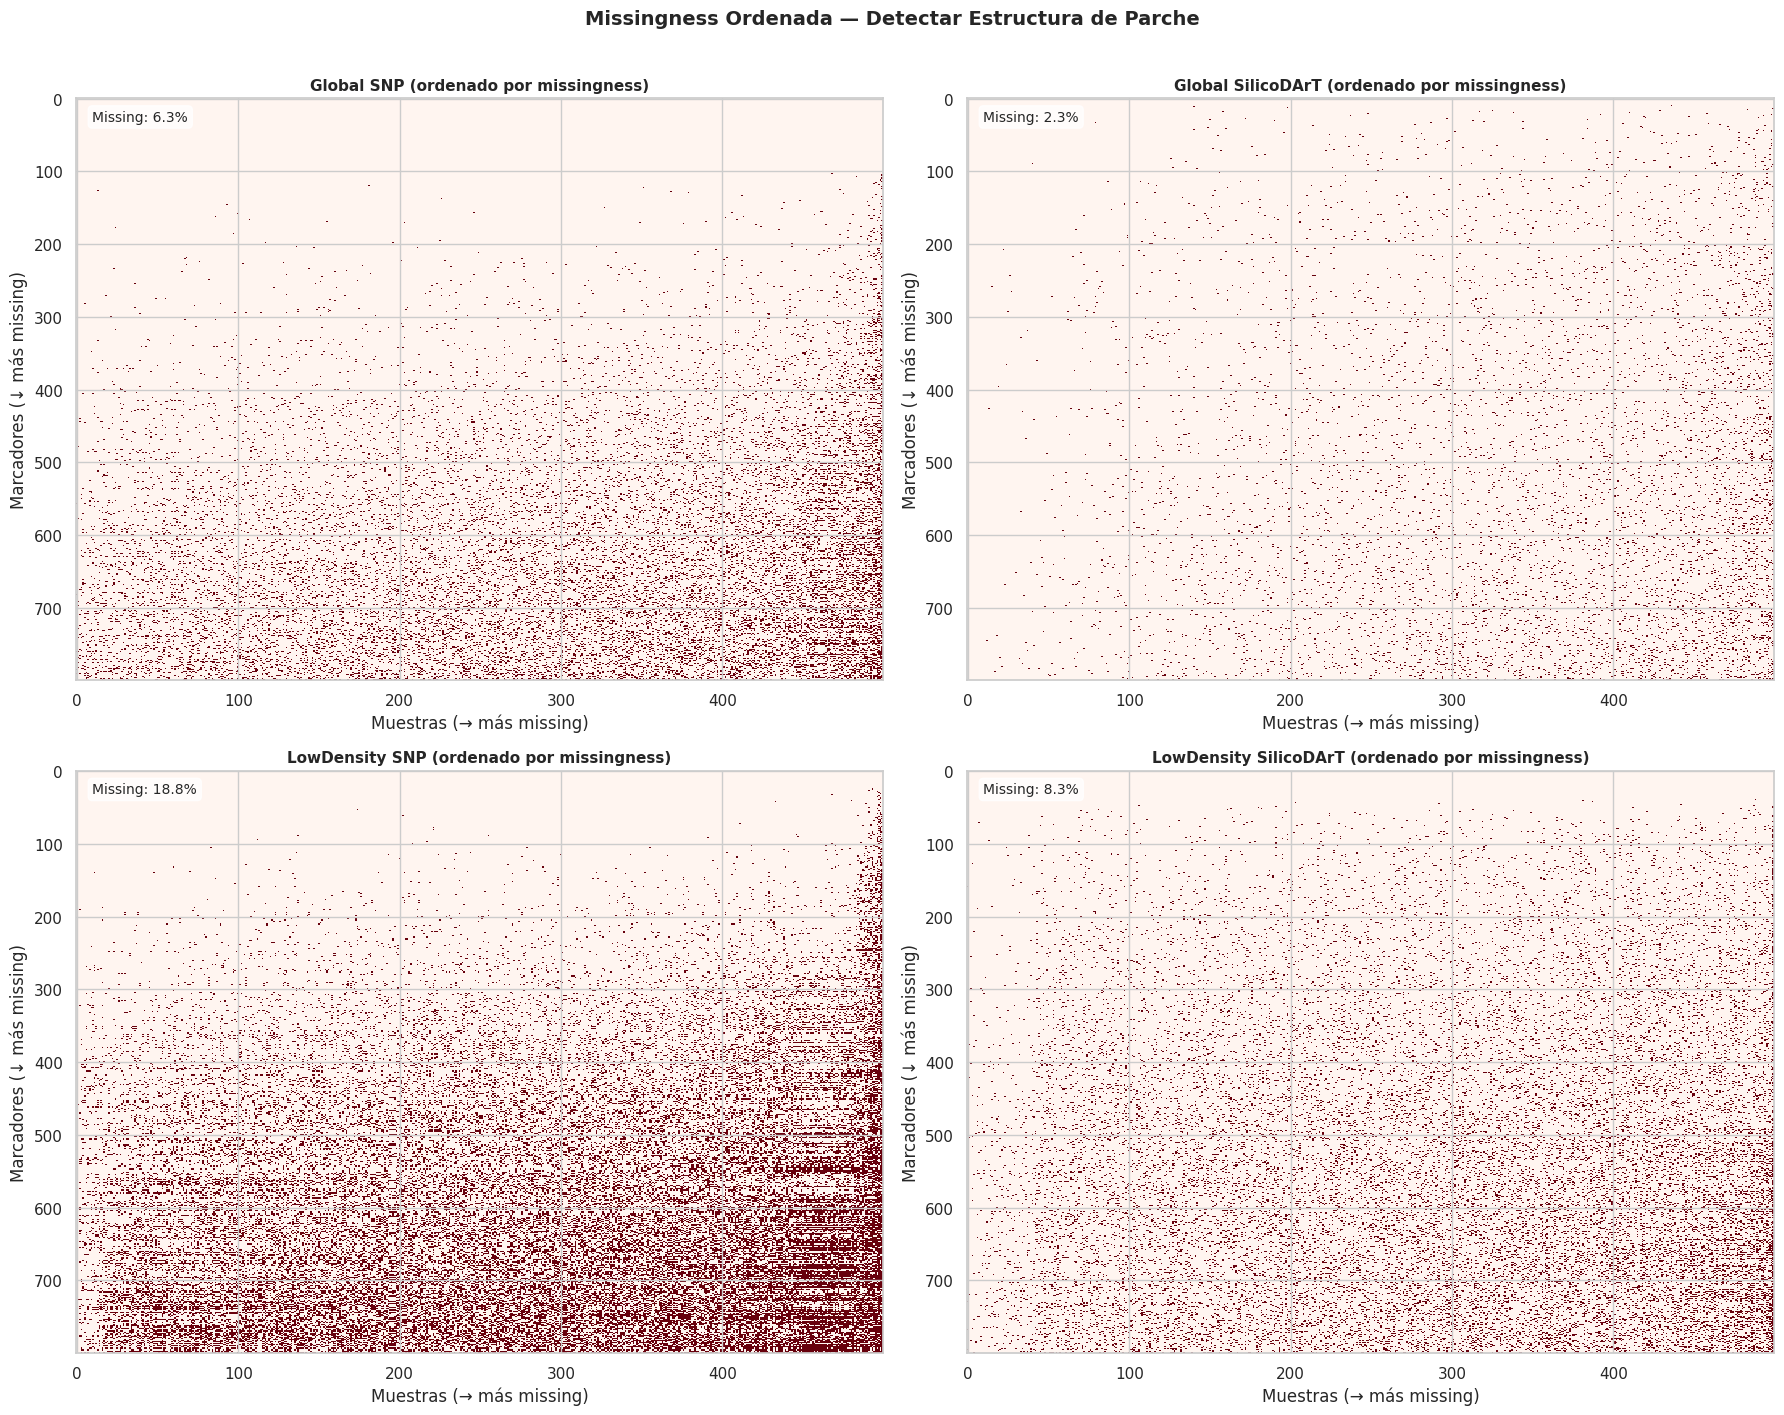


🔍 Si al ordenar aparece un 'triángulo' o 'escalera' en la esquina inferior-derecha:
   → Hay un subconjunto de marcadores que faltan consistentemente en un subconjunto de muestras
   → Esto sugiere batch effect o placa de laboratorio específica


In [11]:
# === 4.4 Heatmaps ORDENADOS por missingness — revelar estructura oculta ===
# Ordenar filas y columnas por % missing para revelar bloques

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (name, geno) in enumerate(geno_cache.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    
    # Subsamplear
    rng = np.random.default_rng(42)
    n_rows = min(800, geno.shape[0])
    n_cols = min(500, geno.shape[1])
    row_idx = np.sort(rng.choice(geno.shape[0], n_rows, replace=False))
    col_idx = np.sort(rng.choice(geno.shape[1], n_cols, replace=False))
    
    sub = geno.iloc[row_idx, col_idx]
    miss_matrix = sub.isna().astype(int)
    
    # Ordenar por missingness: filas (marcadores) por % missing, columnas (muestras) por % missing
    row_order = miss_matrix.mean(axis=1).sort_values().index
    col_order = miss_matrix.mean(axis=0).sort_values().index
    miss_sorted = miss_matrix.loc[row_order, col_order].values
    
    ax.imshow(miss_sorted, aspect="auto", cmap="Reds", interpolation="none")
    ax.set_title(f"{name} (ordenado por missingness)", fontweight="bold", fontsize=11)
    ax.set_xlabel("Muestras (→ más missing)")
    ax.set_ylabel("Marcadores (↓ más missing)")
    
    pct = miss_sorted.mean() * 100
    ax.text(0.02, 0.98, f"Missing: {pct:.1f}%", transform=ax.transAxes,
            fontsize=10, va="top", ha="left",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

for idx in range(len(geno_cache), 4):
    axes[idx].set_visible(False)

plt.suptitle("Missingness Ordenada — Detectar Estructura de Parche", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_heatmaps_sorted.png", dpi=100, bbox_inches="tight")
plt.show()

print("\n🔍 Si al ordenar aparece un 'triángulo' o 'escalera' en la esquina inferior-derecha:")
print("   → Hay un subconjunto de marcadores que faltan consistentemente en un subconjunto de muestras")
print("   → Esto sugiere batch effect o placa de laboratorio específica")

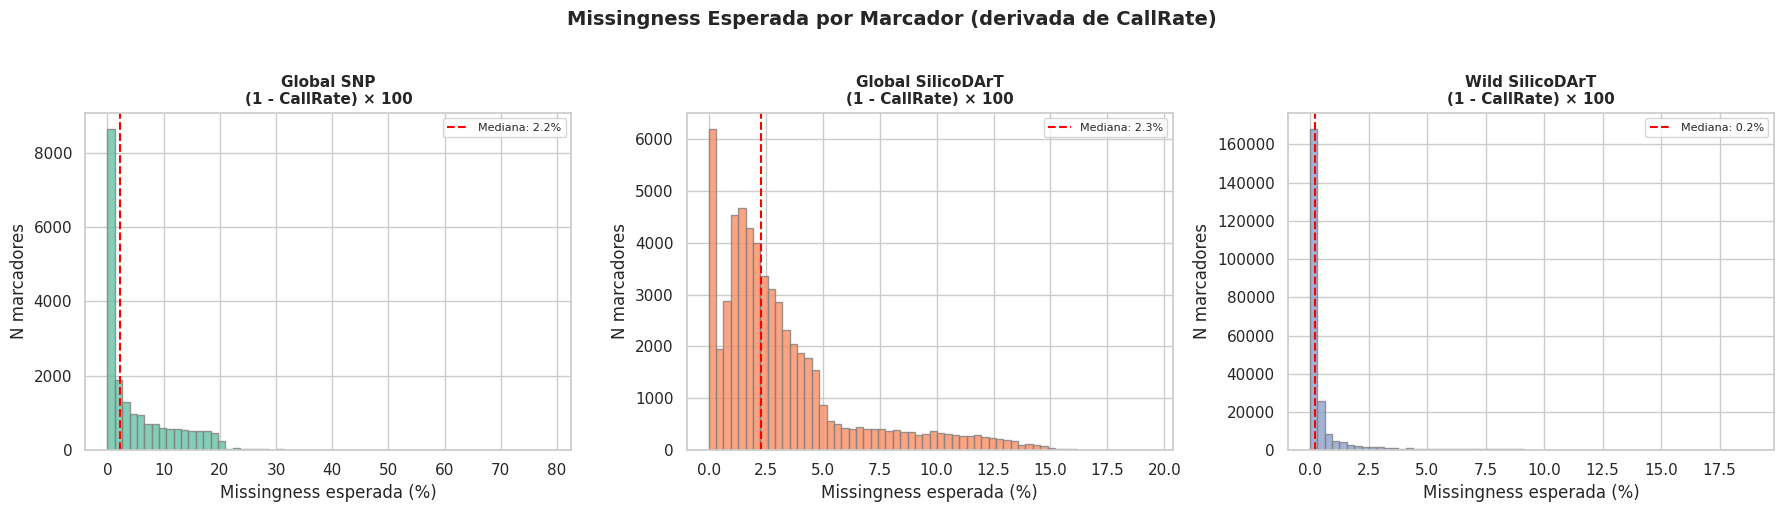

In [12]:
# === 4.5 Correlación Missingness ↔ Métricas de Calidad ===
# Para los datasets con archivos de métricas separados

# Cargar métricas
def load_metrics(path: Path) -> pd.DataFrame:
    sep = detect_sep(path)
    return pd.read_csv(path, sep=sep, low_memory=False)

metrics_data = {}
if FILES["Global SNP metrics"].exists():
    metrics_data["Global SNP"] = load_metrics(FILES["Global SNP metrics"])
if FILES["Global SilicoDArT metrics"].exists():
    metrics_data["Global SilicoDArT"] = load_metrics(FILES["Global SilicoDArT metrics"])
if FILES["Wild SilicoDArT metrics"].exists():
    metrics_data["Wild SilicoDArT"] = load_metrics(FILES["Wild SilicoDArT metrics"])

# Para Global SNP y Global SilicoDArT: cruzar CallRate con missingness observada
# CallRate ya es 1 - missingness teórica, pero verificamos consistencia

fig, axes = plt.subplots(1, len(metrics_data), figsize=(6 * len(metrics_data), 5))
if len(metrics_data) == 1:
    axes = [axes]

md.append("## 4. Missingness Profunda\n\n")
md.append("### Correlación CallRate ↔ Missingness observada\n\n")

for i, (name, df_m) in enumerate(metrics_data.items()):
    ax = axes[i]
    callrate = pd.to_numeric(df_m["CallRate"], errors="coerce").dropna()
    
    # Missingness = 1 - CallRate
    expected_miss = (1 - callrate) * 100
    
    ax.hist(expected_miss, bins=60, alpha=0.8, color=sns.color_palette("Set2")[i], edgecolor="gray")
    ax.axvline(expected_miss.median(), color="red", ls="--",
              label=f"Mediana: {expected_miss.median():.1f}%")
    ax.set_title(f"{name}\n(1 - CallRate) × 100", fontweight="bold", fontsize=11)
    ax.set_xlabel("Missingness esperada (%)")
    ax.set_ylabel("N marcadores")
    ax.legend(fontsize=8)
    
    # Stats
    md.append(f"- **{name}:** CallRate mediana = {callrate.median():.4f}, ")
    md.append(f"missingness esperada mediana = {expected_miss.median():.1f}%, ")
    md.append(f"marcadores con >20% miss = {(expected_miss > 20).sum():,}\n")

plt.suptitle("Missingness Esperada por Marcador (derivada de CallRate)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_vs_callrate.png", dpi=100, bbox_inches="tight")
plt.show()
md.append("\n")

/tmp/ipykernel_116619/458122917.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="chrom", y="miss_pct", order=order, ax=ax,
/tmp/ipykernel_116619/458122917.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="chrom", y="miss_pct", order=order, ax=ax,
/tmp/ipykernel_116619/458122917.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="chrom", y="miss_pct", order=order, ax=ax,


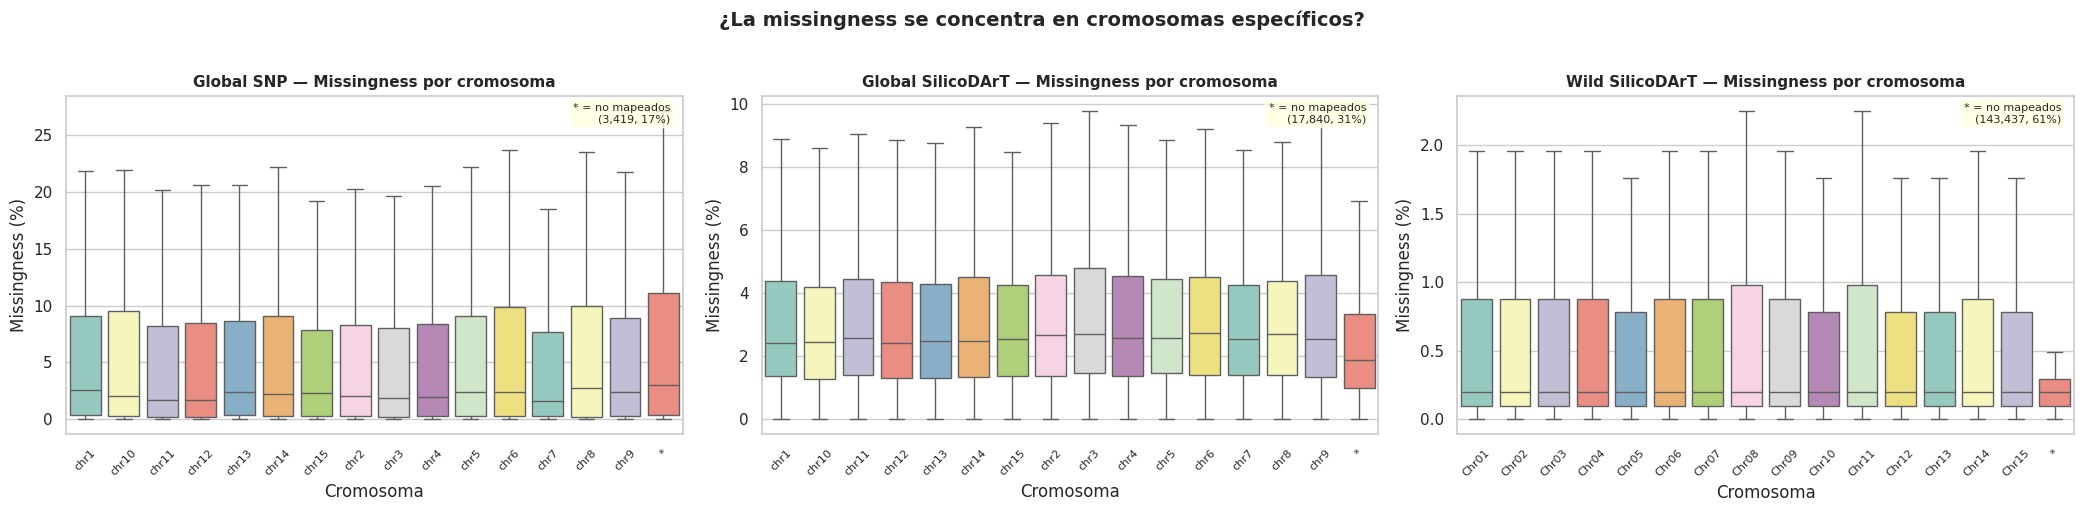

In [13]:
# === 4.6 Missingness por Cromosoma ===
# ¿Los missing se concentran en cromosomas o regiones específicas?

fig, axes = plt.subplots(1, len(metrics_data), figsize=(7 * len(metrics_data), 5))
if len(metrics_data) == 1:
    axes = [axes]

md.append("### Missingness por cromosoma\n\n")

for i, (name, df_m) in enumerate(metrics_data.items()):
    ax = axes[i]
    
    # Encontrar columna de cromosoma
    chrom_col = [c for c in df_m.columns if c.lower().startswith("chrom") and "pos" not in c.lower()]
    if not chrom_col:
        ax.text(0.5, 0.5, "Sin col cromosoma", transform=ax.transAxes, ha="center")
        continue
    
    chrom_col = chrom_col[0]
    callrate = pd.to_numeric(df_m["CallRate"], errors="coerce")
    miss_pct = (1 - callrate) * 100
    
    df_chrom = pd.DataFrame({"chrom": df_m[chrom_col], "miss_pct": miss_pct}).dropna()
    
    # Separar mapeados vs no mapeados
    df_chrom["mapped"] = ~df_chrom["chrom"].isin(["*", "0", ""])
    n_unmapped = (~df_chrom["mapped"]).sum()
    
    # Top 15 cromosomas por frecuencia
    top_chroms = df_chrom[df_chrom["mapped"]]["chrom"].value_counts().head(15).index.tolist()
    if n_unmapped > 0:
        top_chroms.append("*")
    
    df_plot = df_chrom[df_chrom["chrom"].isin(top_chroms)]
    
    # Boxplot por cromosoma
    order = sorted([c for c in top_chroms if c != "*"]) + (["*"] if "*" in top_chroms else [])
    sns.boxplot(data=df_plot, x="chrom", y="miss_pct", order=order, ax=ax,
                palette="Set3", showfliers=False)
    ax.set_title(f"{name} — Missingness por cromosoma", fontweight="bold", fontsize=11)
    ax.set_xlabel("Cromosoma")
    ax.set_ylabel("Missingness (%)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    
    # Anotar unmapped
    if n_unmapped > 0:
        pct_unmapped = n_unmapped / len(df_chrom) * 100
        ax.text(0.98, 0.98, f"* = no mapeados\n({n_unmapped:,}, {pct_unmapped:.0f}%)",
                transform=ax.transAxes, fontsize=8, va="top", ha="right",
                bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    
    md.append(f"- **{name}:** {len(df_chrom):,} marcadores, {n_unmapped:,} no mapeados ({n_unmapped/len(df_chrom)*100:.0f}%)\n")

plt.suptitle("¿La missingness se concentra en cromosomas específicos?", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_by_chrom.png", dpi=100, bbox_inches="tight")
plt.show()
md.append("\n")

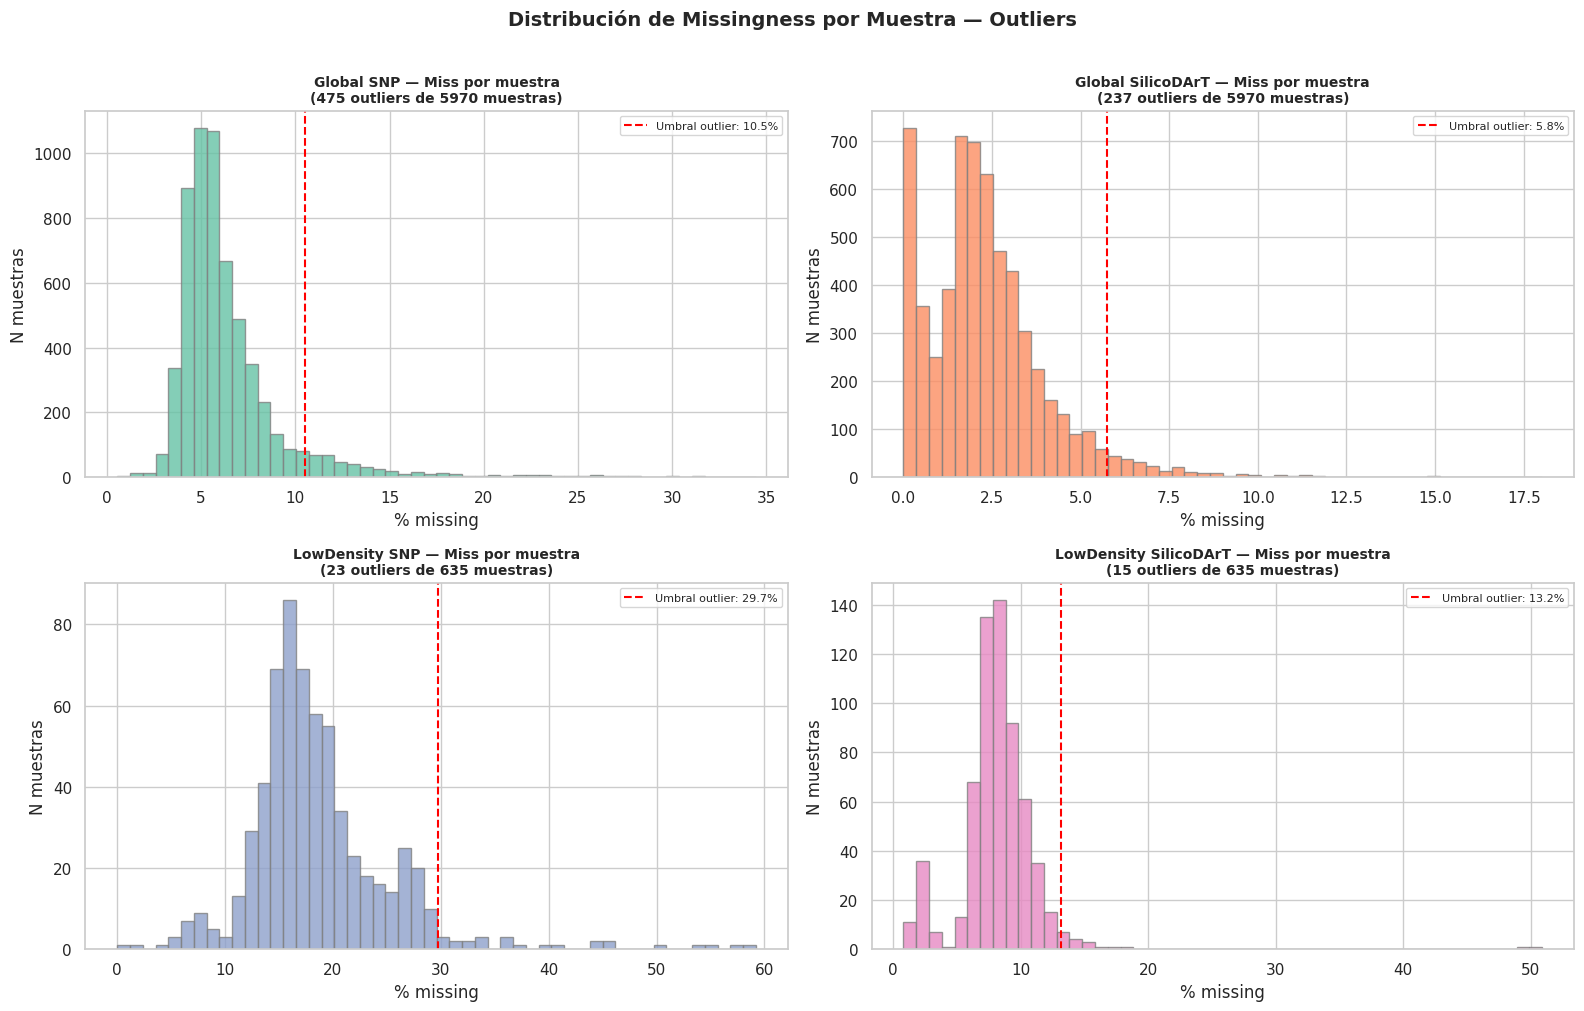

In [14]:
# === 4.7 Co-missingness entre muestras — detectar outliers ===

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

md.append("### Outliers de missingness por muestra\n\n")

for idx, (name, stats) in enumerate(miss_stats.items()):
    if idx >= 4:
        break
    ax = axes[idx]
    miss_per_sample = stats["miss_per_sample"]
    
    # Detectar outliers con IQR
    Q1 = miss_per_sample.quantile(0.25)
    Q3 = miss_per_sample.quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    outliers = miss_per_sample[miss_per_sample > upper]
    
    ax.hist(miss_per_sample, bins=50, alpha=0.8, color=sns.color_palette("Set2")[idx % 8], edgecolor="gray")
    if upper < miss_per_sample.max():
        ax.axvline(upper, color="red", ls="--", lw=1.5, label=f"Umbral outlier: {upper:.1f}%")
    ax.set_title(f"{name} — Miss por muestra\n({len(outliers)} outliers de {len(miss_per_sample)} muestras)",
                fontweight="bold", fontsize=10)
    ax.set_xlabel("% missing")
    ax.set_ylabel("N muestras")
    ax.legend(fontsize=8)
    
    md.append(f"- **{name}:** {len(miss_per_sample)} muestras, {len(outliers)} outliers (>{upper:.1f}% miss), ")
    md.append(f"max = {miss_per_sample.max():.1f}%\n")

for idx in range(len(miss_stats), 4):
    axes[idx].set_visible(False)

plt.suptitle("Distribución de Missingness por Muestra — Outliers", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / "outputs" / "eda_miss_sample_outliers.png", dpi=100, bbox_inches="tight")
plt.show()
md.append("\n")

## 5. Valores Centinela y Codificación

Auditamos qué valores aparecen realmente en las columnas de genotipo
(además de 0, 1, 2 para SNP y 0, 1 para SilicoDArT).

In [15]:
# === 5. Auditoría de valores en columnas de genotipo ===

md.append("## 5. Valores Centinela y Codificación\n\n")

for name, geno in geno_cache.items():
    print(f"\n{'─'*50}")
    print(f"{name} — {geno.shape}")
    print(f"{'─'*50}")
    
    # Aplanar todos los valores y contar
    all_vals = geno.stack().reset_index(drop=True)
    value_counts = all_vals.value_counts(dropna=False).head(20)
    
    print("Top 20 valores:")
    for val, count in value_counts.items():
        pct = count / len(all_vals) * 100
        val_display = repr(val) if pd.isna(val) else str(val)
        print(f"  {val_display:20s}  {count:>12,}  ({pct:.2f}%)")
    
    # Verificar si hay valores inesperados
    expected_snp = {"0", "1", "2", "0.0", "1.0", "2.0"}
    expected_silico = {"0", "1", "0.0", "1.0"}
    
    non_null = all_vals.dropna().astype(str)
    unique_vals = set(non_null.unique())
    
    is_snp = "SNP" in name
    expected = expected_snp if is_snp else expected_silico
    unexpected = unique_vals - expected
    
    if unexpected:
        n_unexpected = sum(non_null.isin(unexpected))
        print(f"\n  ⚠️ Valores inesperados: {len(unexpected)} tipos, {n_unexpected:,} ocurrencias")
        for v in sorted(unexpected)[:10]:
            print(f"     {repr(v)}: {(non_null == v).sum():,}")
    else:
        print(f"\n  ✅ Solo valores esperados ({', '.join(sorted(expected))}) + NaN")
    
    md.append(f"**{name}:** ")
    md.append(f"{len(unique_vals)} valores únicos. ")
    if unexpected:
        md.append(f"⚠️ {len(unexpected)} tipos inesperados ({n_unexpected:,} ocurrencias)\n\n")
    else:
        md.append(f"✅ Solo valores esperados\n\n")


──────────────────────────────────────────────────
Global SNP — (1998, 5970)
──────────────────────────────────────────────────
Top 20 valores:
  0                        6,024,602  (50.51%)
  2                        3,447,514  (28.90%)
  1                        1,680,275  (14.09%)
  nan                        775,669  (6.50%)

  ✅ Solo valores esperados (0, 0.0, 1, 1.0, 2, 2.0) + NaN

──────────────────────────────────────────────────
Global SilicoDArT — (1998, 5970)
──────────────────────────────────────────────────
Top 20 valores:
  0                        8,076,531  (67.71%)
  1                        3,573,138  (29.96%)
  nan                        278,391  (2.33%)

  ✅ Solo valores esperados (0, 0.0, 1, 1.0) + NaN

──────────────────────────────────────────────────
LowDensity SNP — (2000, 635)
──────────────────────────────────────────────────
Top 20 valores:
  1                          568,692  (44.78%)
  0                          464,038  (36.54%)
  nan                   

In [16]:
# === 5.2 Valores centinela en columnas genómicas ===
# Verificar: AlnEvalue=999 y ChromPos=0 siempre co-ocurren con Chrom=*?

md.append("### Valores centinela en columnas genómicas\n\n")

for name, df_m in metrics_data.items():
    print(f"\n{'─'*50}")
    print(f"{name}")
    print(f"{'─'*50}")
    
    # Encontrar columnas relevantes
    chrom_col = [c for c in df_m.columns if c.lower().startswith("chrom") and "pos" not in c.lower() and "tag" not in c.lower()]
    pos_col = [c for c in df_m.columns if "chrompos" in c.lower() or "chrompostag" in c.lower()]
    evalue_col = [c for c in df_m.columns if "evalue" in c.lower()]
    
    if chrom_col:
        chrom = df_m[chrom_col[0]]
        unmapped = chrom.isin(["*", "0", ""])
        print(f"  Chrom: {chrom_col[0]}")
        print(f"    No mapeados (*): {unmapped.sum():,} / {len(chrom):,} ({unmapped.mean()*100:.1f}%)")
        
        if pos_col:
            pos = pd.to_numeric(df_m[pos_col[0]], errors="coerce")
            pos_zero_when_unmapped = (pos[unmapped] == 0).mean() * 100 if unmapped.any() else 0
            print(f"  ChromPos=0 cuando Chrom=*: {pos_zero_when_unmapped:.1f}%")
        
        if evalue_col:
            ev = pd.to_numeric(df_m[evalue_col[0]], errors="coerce")
            ev_999_when_unmapped = (ev[unmapped] == 999).mean() * 100 if unmapped.any() else 0
            print(f"  AlnEvalue=999 cuando Chrom=*: {ev_999_when_unmapped:.1f}%")
        
        md.append(f"- **{name}:** {unmapped.sum():,} marcadores no mapeados ({unmapped.mean()*100:.1f}%). ")
        if pos_col and evalue_col:
            md.append(f"ChromPos=0 y AlnEvalue=999 co-ocurren con Chrom=* al {min(pos_zero_when_unmapped, ev_999_when_unmapped):.0f}%\n")
        else:
            md.append("\n")

md.append("\n")


──────────────────────────────────────────────────
Global SNP
──────────────────────────────────────────────────
  Chrom: Chrom_SweetPotato_unkn_v4
    No mapeados (*): 3,419 / 20,101 (17.0%)
  ChromPos=0 cuando Chrom=*: 100.0%
  AlnEvalue=999 cuando Chrom=*: 100.0%

──────────────────────────────────────────────────
Global SilicoDArT
──────────────────────────────────────────────────
  Chrom: Chrom_SweetPotato_unkn_v4
    No mapeados (*): 17,840 / 57,715 (30.9%)
  ChromPos=0 cuando Chrom=*: 100.0%
  AlnEvalue=999 cuando Chrom=*: 100.0%

──────────────────────────────────────────────────
Wild SilicoDArT
──────────────────────────────────────────────────
  Chrom: Chrom_SweetPotato_NSP323_v3
    No mapeados (*): 143,437 / 236,607 (60.6%)
  ChromPos=0 cuando Chrom=*: 100.0%
  AlnEvalue=999 cuando Chrom=*: 100.0%


## 6. Resumen y Exportación

Consolidamos todos los hallazgos y exportamos a `docs/code_analysis/EDA_VARIABLES.md`.

In [17]:
# === 6. Exportar EDA_VARIABLES.md ===

header = f"""# 🔬 EDA: Variables y Missingness — OXOR / GENO-MAP

> **Generado automáticamente** por `notebooks/eda_variables.ipynb`  
> **Fecha:** {datetime.now().strftime('%Y-%m-%d %H:%M')}

---

## TL;DR

"""

# Construir TL;DR dinámico
tldr_lines = []
tldr_lines.append(f"- **Archivos analizados:** {len(GENO_FILES)} genotipos + {len(metrics_data)} métricas")

if is_duplicate:
    tldr_lines.append("- ⚠️ **Duplicado confirmado:** LowDensity SNP y Wild SNP son el MISMO archivo (MD5 idéntico)")

for name, stats in miss_stats.items():
    tldr_lines.append(f"- **{name}:** {stats['shape'][0]:,}×{stats['shape'][1]:,}, missingness global = {stats['miss_global']:.1f}%")

# Detectar si hay patrones de parche
high_miss_datasets = [n for n, s in miss_stats.items() if s["miss_global"] > 10]
if high_miss_datasets:
    tldr_lines.append(f"- 🔍 **Missingness alta (>10%):** {', '.join(high_miss_datasets)} — revisar heatmaps para patrones de parche")

tldr = "\n".join(tldr_lines) + "\n\n---\n\n"

# Ensamblar
catalog = header + tldr + "\n".join(md)

# Escribir
out_path = DOC_CODE_DIR / "EDA_VARIABLES.md"
with open(out_path, "w") as f:
    f.write(catalog)

print(f"✅ Exportado: {out_path}")
print(f"   {len(catalog):,} caracteres, {catalog.count(chr(10)):,} líneas")
display(Markdown("---\n### Vista previa (primeras 60 líneas):\n\n" + "\n".join(catalog.split("\n")[:60])))

✅ Exportado: ../docs/code_analysis/EDA_VARIABLES.md
   14,712 caracteres, 515 líneas


---
### Vista previa (primeras 60 líneas):

# 🔬 EDA: Variables y Missingness — OXOR / GENO-MAP

> **Generado automáticamente** por `notebooks/eda_variables.ipynb`  
> **Fecha:** 2026-03-01 01:41

---

## TL;DR

- **Archivos analizados:** 4 genotipos + 3 métricas
- ⚠️ **Duplicado confirmado:** LowDensity SNP y Wild SNP son el MISMO archivo (MD5 idéntico)
- **Global SNP:** 1,998×5,970, missingness global = 6.5%
- **Global SilicoDArT:** 1,998×5,970, missingness global = 2.3%
- **LowDensity SNP:** 2,000×635, missingness global = 18.7%
- **LowDensity SilicoDArT:** 2,000×635, missingness global = 8.2%
- 🔍 **Missingness alta (>10%):** LowDensity SNP — revisar heatmaps para patrones de parche

---

## 1. Diccionario de Variables (Data Dictionary xlsx)


### Hoja: Hoja1 (236,610 filas → 4 definiciones únicas)


| Variable name   | Abbreviation   | Context of use   | Description                                | Unit   | Category 1   | Category 2   | Category 3      |
|:----------------|:---------------|:-----------------|:-------------------------------------------|:-------|:-------------|:-------------|:----------------|
| Sample_code     | N              | sample code      | Numeric identifier of samples              | number | nan          | nan          | nan             |
| Country_origin  | ORIGCNTRY      | Passport data    | Country of origin of sweetpotato germplasm | text   | nan          | nan          | nan             |
| Accession       | ACCSNUMBER     | Passport data    | Accession identifier                       | text   | nan          | nan          | nan             |
| 7529063         | DARTGENOTYPE   | Data             | Presence/absence of a SilicoDArT fragment. | number | 1 =presence  | 0 =absence   | 9 =missing data |


## 2. Inventario de Columnas por Archivo


| Archivo                   |   Total cols |   ID |   Secuencia |   Genómica |   Calidad |   Muestra |   Otro | Sep   |
|:--------------------------|-------------:|-----:|------------:|-----------:|----------:|----------:|-------:|:------|
| Global SNP geno           |         5971 |    0 |           0 |          0 |         0 |      5970 |      1 | ','   |
| Global SNP metrics        |           25 |    3 |           2 |         10 |        10 |         0 |      0 | ','   |
| Global SilicoDArT geno    |         5971 |    0 |           0 |          0 |         0 |      5970 |      1 | ','   |
| Global SilicoDArT metrics |           14 |    1 |           2 |          4 |         7 |         0 |      0 | ','   |
| LowDensity SNP            |          667 |    2 |           1 |         10 |        11 |       635 |      8 | ','   |
| LowDensity SilicoDArT     |          650 |    1 |           1 |          0 |         9 |       635 |      4 | ','   |
| Wild SNP                  |          667 |    2 |           1 |         10 |        11 |       635 |      8 | ','   |
| Wild SilicoDArT metrics   |           15 |    1 |           2 |          5 |         7 |         0 |      0 | ';'   |


### Detalle de columnas no-muestra



**Global SNP geno** (1 metadatos, 5970 muestras)


| Columna | Categoría |
|---------|-----------|

| ﻿Sample_code | Otro |
